## Imports e configs iniciais

In [2]:
import os
import glob
import re
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configuração para exibir gráficos no notebook
%matplotlib inline

# Definição dos caminhos das pastas
BASE_DIR = Path("..")
DATA_RAW = BASE_DIR / "data" / "raw"

PATH_IMAGES = DATA_RAW / "BBBC020_v1_images"
PATH_OUTLINES_CELLS = DATA_RAW / "BBC020_v1_outlines_cells"
PATH_OUTLINES_NUCLEI = DATA_RAW / "BBC020_v1_outlines_nuclei"

# Pasta de saída para os dados processados
PATH_PROCESSED = BASE_DIR / "data" / "processed"
PATH_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Estrutura de caminhos configurada com sucesso.")

Estrutura de caminhos configurada com sucesso.


## mapeando e limpando os arquivos

In [3]:
def obter_mapeamento_imagens(pasta_imagens):
    mapeamento = {}
    
    # Listar subpastas (ex: jw-15min 1, jw-15min 2)
    for pasta_camada in pasta_imagens.iterdir():
        if pasta_camada.is_dir():
            nome_imagem = pasta_camada.name
            mapeamento[nome_imagem] = {}
            
            # Buscar apenas arquivos .TIF
            arquivos_tif = list(pasta_camada.glob("*.TIF")) + list(pasta_camada.glob("*.tif"))
            
            for arq in arquivos_tif:
                nome_arq = arq.name
                if "_(c1+c5)" in nome_arq:
                    mapeamento[nome_imagem]["merged"] = arq
                elif "_c1" in nome_arq:
                    mapeamento[nome_imagem]["cell"] = arq
                elif "_c5" in nome_arq:
                    mapeamento[nome_imagem]["nucleus"] = arq
                    
    return mapeamento

dict_imagens = obter_mapeamento_imagens(PATH_IMAGES)
print(f"Total de imagens mapeadas: {len(dict_imagens)}")
# Exemplo do primeiro mapeamento
primeira_chave = list(dict_imagens.keys())[0]
print(f"Exemplo de mapeamento para '{primeira_chave}':\n", dict_imagens[primeira_chave])

Total de imagens mapeadas: 25
Exemplo de mapeamento para 'jw-15min 1':
 {'merged': WindowsPath('../data/raw/BBBC020_v1_images/jw-15min 1/jw-15min 1_(c1+c5).TIF'), 'cell': WindowsPath('../data/raw/BBBC020_v1_images/jw-15min 1/jw-15min 1_c1.TIF'), 'nucleus': WindowsPath('../data/raw/BBBC020_v1_images/jw-15min 1/jw-15min 1_c5.TIF')}


### vendo imagens brutas

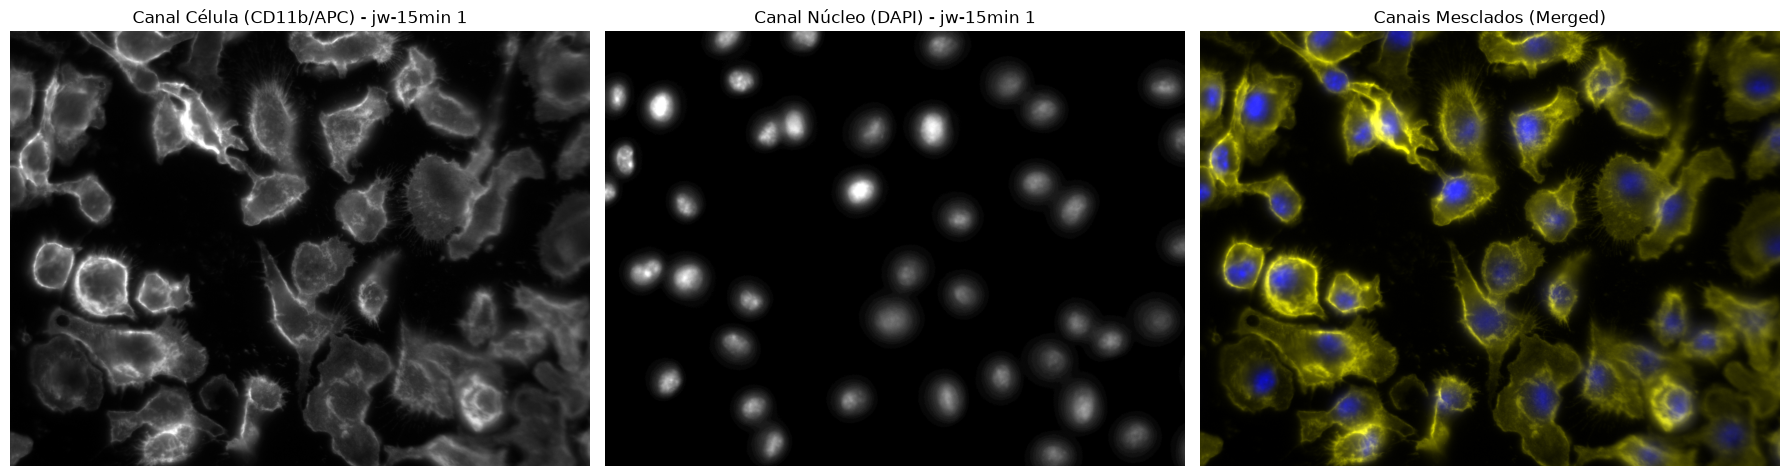

In [4]:
# primeira imagem do dicionário
id_exemplo = list(dict_imagens.keys())[0]

# Carrega as imagens usando OpenCV (IMREAD_UNCHANGED para preservar profundidade de bits se houver)
img_cell = cv2.imread(str(dict_imagens[id_exemplo]["cell"]), cv2.IMREAD_GRAYSCALE)
img_nucleus = cv2.imread(str(dict_imagens[id_exemplo]["nucleus"]), cv2.IMREAD_GRAYSCALE)
img_merged = cv2.imread(str(dict_imagens[id_exemplo]["merged"]))
img_merged = cv2.cvtColor(img_merged, cv2.COLOR_BGR2RGB)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_cell, cmap='gray')
axes[0].set_title(f"Canal Célula (CD11b/APC) - {id_exemplo}")

axes[1].imshow(img_nucleus, cmap='gray')
axes[1].set_title(f"Canal Núcleo (DAPI) - {id_exemplo}")

axes[2].imshow(img_merged)
axes[2].set_title("Canais Mesclados (Merged)")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### agregação dos contornos (ground truth)

como o dataset entrega um arquivo por contorno, precisamos juntar todos. alem disso, por se tratar de "outlines" (apenas a linha da borda), é ideal preencher o interior do contorno para criar uma máscara binária/rótulo sólida que facilite a validação posterior.

In [5]:
def consolidar_ground_truth(id_imagem, pasta_outlines, sufixo_canal, formato_saida):
    """
    Busca todos os arquivos de contorno de uma imagem e os consolida em uma única máscara.
    formato_saida: 'binary' (0 e 255) ou 'labeled' (0, 1, 2, 3... para cada célula)
    """
    # Regex para encontrar os arquivos correspondentes, ex: jw-15min 1_c1_0.TIF, jw-15min 1_c1_1.TIF ...
    # Escapa caracteres especiais do ID da imagem se houver
    padrao_busca = str(pasta_outlines / f"{id_imagem}_{sufixo_canal}_*.TIF")
    arquivos_contorno = glob.glob(padrao_busca)
    
    if not arquivos_contorno:
        return None
    
    # Carrega a primeira para descobrir as dimensões da imagem
    img_base = cv2.imread(arquivos_contorno[0], cv2.IMREAD_GRAYSCALE)
    h, w = img_base.shape
    
    # Cria a matriz acumuladora
    if formato_saida == 'labeled':
        mascara_consolidada = np.zeros((h, w), dtype=np.int32)
    else:
        mascara_consolidada = np.zeros((h, w), dtype=np.uint8)
        
    for idx, caminho_arq in enumerate(arquivos_contorno, start=1):
        contorno_individual = cv2.imread(caminho_arq, cv2.IMREAD_GRAYSCALE)
        
        # Como são 'outlines', precisamos preencher o interior do contorno
        # Encontramos os pontos do contorno para usar a função de preenchimento do OpenCV
        contornos, _ = cv2.findContours(contorno_individual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        mascara_preenchida = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(mascara_preenchida, contornos, -1, color=255, thickness=cv2.FILLED)
        
        # Atribui à máscara final
        if formato_saida == 'labeled':
            # Atribui um ID único para cada célula (ótimo para contar depois)
            mascara_consolidada[mascara_preenchida > 0] = idx
        else:
            # Máscara binária simples
            mascara_consolidada[mascara_preenchida > 0] = 255
            
    return mascara_consolidada

Exibindo gabarito da imagem: jw-15min 1


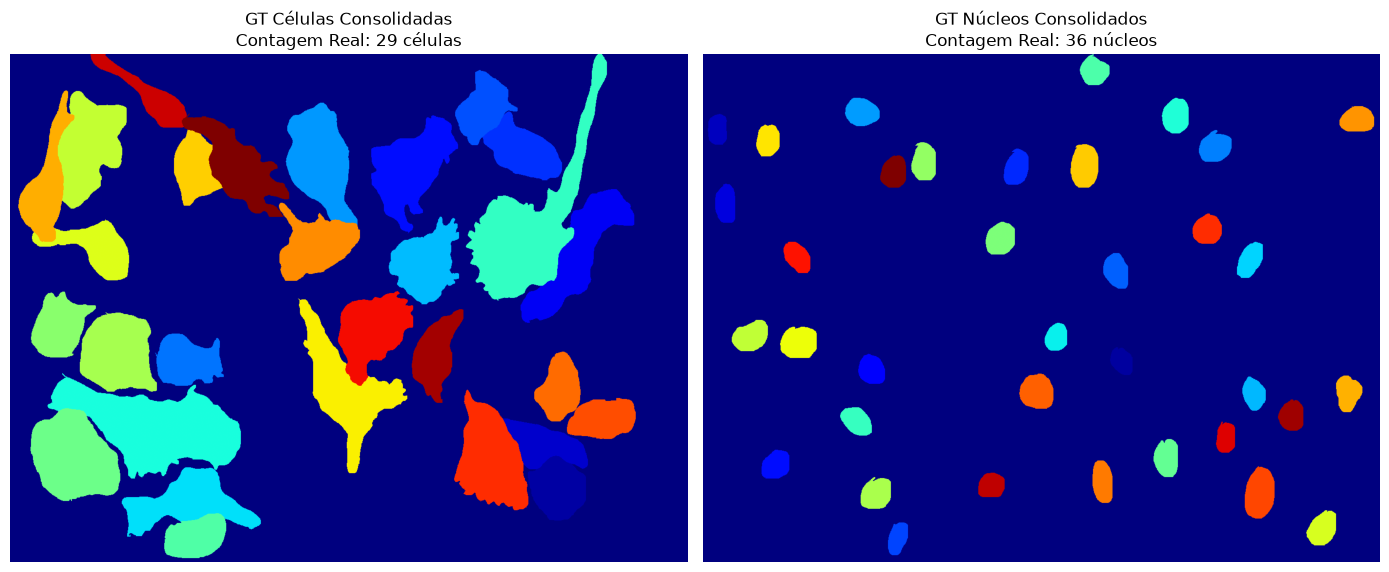

In [6]:
# Procura a primeira imagem no dicionário que realmente possua arquivos de GT
id_exemplo_gt = None
mask_cell_gt = None
mask_nucleus_gt = None

for id_img in dict_imagens.keys():
    mask_teste = consolidar_ground_truth(id_img, PATH_OUTLINES_CELLS, "c1", formato_saida='labeled')
    if mask_teste is not None:
        id_exemplo_gt = id_img
        mask_cell_gt = mask_teste
        mask_nucleus_gt = consolidar_ground_truth(id_img, PATH_OUTLINES_NUCLEI, "c5", formato_saida='labeled')
        break # Para no primeiro que encontrar

if id_exemplo_gt is None:
    print("Nenhum gabarito encontrado! Verifique se os arquivos foram descompactados corretamente nas pastas outlines.")
else:
    print(f"Exibindo gabarito da imagem: {id_exemplo_gt}")
    
    # Contagem real de células pelo gabarito
    num_celulas_gt = np.max(mask_cell_gt) if mask_cell_gt is not None else 0
    num_nucleos_gt = np.max(mask_nucleus_gt) if mask_nucleus_gt is not None else 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    if mask_cell_gt is not None:
        axes[0].imshow(mask_cell_gt, cmap='jet')
        axes[0].set_title(f"GT Células Consolidadas\nContagem Real: {num_celulas_gt} células")
    else:
        axes[0].text(0.5, 0.5, "Sem dados de GT para Células", ha='center')

    if mask_nucleus_gt is not None:
        axes[1].imshow(mask_nucleus_gt, cmap='jet')
        axes[1].set_title(f"GT Núcleos Consolidados\nContagem Real: {num_nucleos_gt} núcleos")
    else:
        axes[1].text(0.5, 0.5, "Sem dados de GT para Núcleos", ha='center')

    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

## salvando em formato numpy

In [7]:
# Criar subpastas em processed
(PATH_PROCESSED / "01_ground_truth" / "gt_cells").mkdir(parents=True, exist_ok=True)
(PATH_PROCESSED / "01_ground_truth" / "gt_nuclei").mkdir(parents=True, exist_ok=True)

ids_com_gt = []

for id_imagem in dict_imagens.keys():
    # Processa células
    gt_cell = consolidar_ground_truth(id_imagem, PATH_OUTLINES_CELLS, "c1", formato_saida='labeled')
    if gt_cell is not None:
        np.save(PATH_PROCESSED / "01_ground_truth" / "gt_cells" / f"{id_imagem}_gt_cells.npy", gt_cell)

    # Processa núcleos
    gt_nucleus = consolidar_ground_truth(id_imagem, PATH_OUTLINES_NUCLEI, "c5", formato_saida='labeled')
    if gt_nucleus is not None:
        np.save(PATH_PROCESSED / "01_ground_truth" / "gt_nuclei" / f"{id_imagem}_gt_nuclei.npy", gt_nucleus)

    # Se ao menos um dos dois GT existir, considera imagem com gabarito
    if gt_cell is not None or gt_nucleus is not None:
        ids_com_gt.append(id_imagem)

print("Processamento concluído! Todos os gabaritos foram gerados e salvos em 'data/processed/'.")

Iniciando o processamento de todo o dataset.
Processamento concluído! Todos os gabaritos foram gerados e salvos em 'data/processed/'.
